# EDA — End-to-End Data Audit (Raw → Processed → Analytics)

This notebook performs a **full data-quality and coverage analysis** across all pipeline layers:

1. **Raw scrape payloads** (`data/raw/shopify`, `data/raw/woocommerce`)
2. **Processed datasets** (`data/processed/*.parquet`)
3. **Analytics outputs** (`data/analytics/*.csv`, `*.json`, `*.jsonl`)

Use this as a diagnostic baseline before scraper hardening and validation rule updates.


In [9]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

BASE = Path("../data")
RAW_DIR = BASE / "raw"
PROCESSED_DIR = BASE / "processed"
ANALYTICS_DIR = BASE / "analytics"

SHOPIFY_DIR = RAW_DIR / "shopify"
WOOCOMMERCE_DIR = RAW_DIR / "woocommerce"

print("Data root:", BASE.resolve())
print("Raw dir exists:", RAW_DIR.exists())
print("Processed dir exists:", PROCESSED_DIR.exists())
print("Analytics dir exists:", ANALYTICS_DIR.exists())


def safe_read_json(path: Path):
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None


def normalize_raw_records(payload, source_file: str, platform: str):
    """Return normalized list[dict] from heterogeneous raw payload formats."""
    if payload is None:
        return []

    candidates = []
    if isinstance(payload, list):
        candidates = payload
    elif isinstance(payload, dict):
        for key in ["products", "items", "data"]:
            if key in payload and isinstance(payload[key], list):
                candidates = payload[key]
                break
        if not candidates:
            # fallback: treat dict itself as one record if it looks product-like
            if any(k in payload for k in ["title", "name", "product_id", "id", "url"]):
                candidates = [payload]

    normalized = []
    for rec in candidates:
        if not isinstance(rec, dict):
            continue

        product_id = rec.get("product_id") or rec.get("id") or rec.get("sku")
        title = rec.get("title") or rec.get("name")
        description = rec.get("description") or rec.get("body_html") or rec.get("short_description")
        category = rec.get("category") or rec.get("product_type") or rec.get("type")
        brand = rec.get("brand") or rec.get("vendor")

        price = rec.get("price")
        old_price = rec.get("old_price") or rec.get("compare_at_price") or rec.get("regular_price")

        rating = rec.get("rating") or rec.get("average_rating")
        review_count = rec.get("review_count") or rec.get("rating_count")

        availability = rec.get("availability") or rec.get("stock_status")
        product_url = rec.get("product_url") or rec.get("url") or rec.get("permalink")
        shop_name = rec.get("shop_name") or rec.get("shop")

        normalized.append(
            {
                "source_file": source_file,
                "source_platform": platform,
                "product_id": product_id,
                "title": title,
                "description": description,
                "category": category,
                "brand": brand,
                "price": price,
                "old_price": old_price,
                "rating": rating,
                "review_count": review_count,
                "availability": availability,
                "product_url": product_url,
                "shop_name": shop_name,
            }
        )
    return normalized


def pct(x):
    return f"{100 * x:.1f}%"

Data root: /home/medgm/vsc/smart-ecommerce-pipeline/data
Raw dir exists: True
Processed dir exists: True
Analytics dir exists: True


=== RAW AUDIT ===
Raw records loaded: 634
Raw columns: ['source_file', 'source_platform', 'product_id', 'title', 'description', 'category', 'brand', 'price', 'old_price', 'rating', 'review_count', 'availability', 'product_url', 'shop_name']


,source_file,source_platform,product_id,title,description,category,brand,price,old_price,rating,review_count,availability,product_url,shop_name
0,death_wish_coffee.json,shopify,7345274486839,"Organic Cold Brew Coffee, Unsweetened",Cure for chaos. \n Unbelievably smooth and ser...,Coffee,Death Wish Coffee,5.99,NaN,NaN,NaN,out of stock,https://www.deathwishcoffee.com/products/organ...,Death Wish Coffee
1,death_wish_coffee.json,shopify,4346529579063,Dark Roast Instant Coffee,Get lifted. Instantly. \n Ever been at a cruis...,Coffee,Death Wish Coffee Company,11.99,NaN,NaN,NaN,out of stock,https://www.deathwishcoffee.com/products/death...,Death Wish Coffee
2,death_wish_coffee.json,shopify,179754517,Death Wish Coffee Digital Gift Card,Give the gift they really want. \n Buy a virtu...,Gift Card,Death Wish Coffee Company,25.00,NaN,NaN,NaN,out of stock,https://www.deathwishcoffee.com/products/gift-...,Death Wish Coffee
3,death_wish_coffee.json,shopify,7361969684535,2026 Death Wish Coffee Mug,Mugs up to 2026. \n A symbol of new beginning...,Mugs,Deneen Pottery,38.00,NaN,NaN,NaN,out of stock,https://www.deathwishcoffee.com/products/2026-...,Death Wish Coffee
4,death_wish_coffee.json,shopify,371580108813,6 Cup Chemex (with filters),The perfect pot. \n You're a cup above the res...,Storage & Brewing,Death Wish Coffee Company,60.00,NaN,NaN,NaN,out of stock,https://www.deathwishcoffee.com/products/6-cup...,Death Wish Coffee



Raw required-field coverage:


,field,filled,total,coverage
4,category,394,634,62.1%
3,price,554,634,87.4%
1,title,634,634,100.0%
0,product_id,634,634,100.0%
2,product_url,634,634,100.0%
5,shop_name,634,634,100.0%


Potential duplicates by URL: 0
Potential duplicates by (title, shop): 4

Records by platform:


source_platform
woocommerce    401
shopify        233
Name: count, dtype: int64


Top shops by raw record count:


shop_name
NutriBullet          184
Dan-O's Seasoning    125
Nalgene               92
Ruggable              71
Fashion Nova          66
Turtle Beach          59
Death Wish Coffee     29
Hiut Denim             8
Name: count, dtype: int64

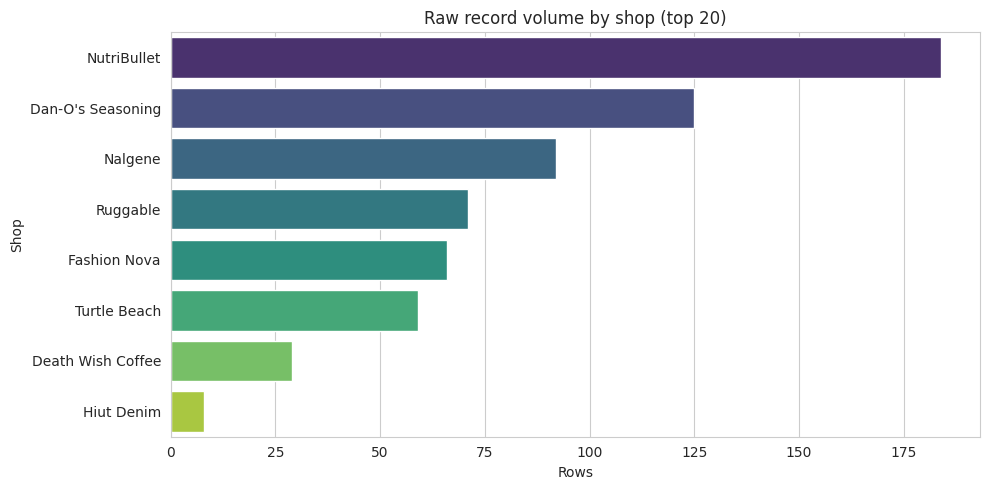


=== PROCESSED AUDIT ===
cleaned_products shape: (634, 40)
features shape: (634, 50)

DQ counters artifact (dq_counters.json):


,value
rows_total,634
missing_price,80
missing_category,240
missing_rating,533
duplicates_core_key,0
...,...
dq_score_p50,89.5
dq_score_p75,89.5
schema_version,2.2.0
extraction_version,fallback-v3-taxonomy-evidence


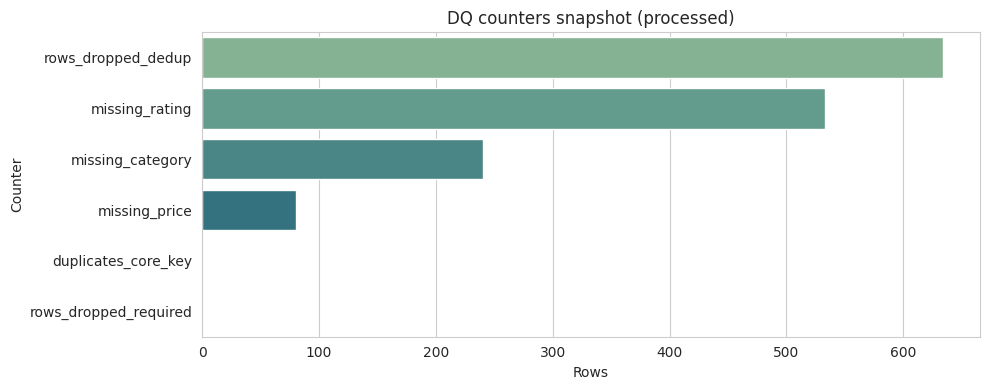


Cleaned sample:


,product_id,title,shop_name,source_platform,category,price,rating,review_count
0,freya-smocked-linen-maxi-dress-chocolate,Freya Smocked Linen Maxi Dress Chocolate,Fashion Nova,shopify,uncategorized,35.99,NaN,0
1,never-average-plisse-maxi-dress-gold,Never Average Plisse Maxi Dress Gold,Fashion Nova,shopify,uncategorized,39.99,NaN,0
2,mariana-halter-pant-set-olive,Mariana Halter Pant Set Olive,Fashion Nova,shopify,uncategorized,35.99,NaN,0
3,wild-seduction-zebra-chiffon-maxi-top-black-combo,Wild Seduction Zebra Chiffon Maxi Top Black Combo,Fashion Nova,shopify,uncategorized,30.99,4.857143,21
4,ava-button-up-short-set-chocolate,Ava Button Up Short Set Chocolate,Fashion Nova,shopify,uncategorized,14.99,NaN,0
5,mina-bandeau-halter-chiffon-sarong-3-piece-bik...,Mina Bandeau Halter Chiffon Sarong 3 Piece Bik...,Fashion Nova,shopify,uncategorized,32.49,4.580000,50
6,ed-hardy-nyc-wide-leg-pant-black,Ed Hardy Nyc Wide Leg Pant Black,Fashion Nova,shopify,uncategorized,49.99,4.536332,289
7,st-clair-cuffed-denim-bermuda-shorts-medium-wash,St Clair Cuffed Denim Bermuda Shorts Medium Wash,Fashion Nova,shopify,uncategorized,30.99,5.000000,1



Processed quality counters:


,count
missing_product_id,0
missing_title,0
missing_url,0
missing_price,80
uncategorized,240
duplicate_core_key,0


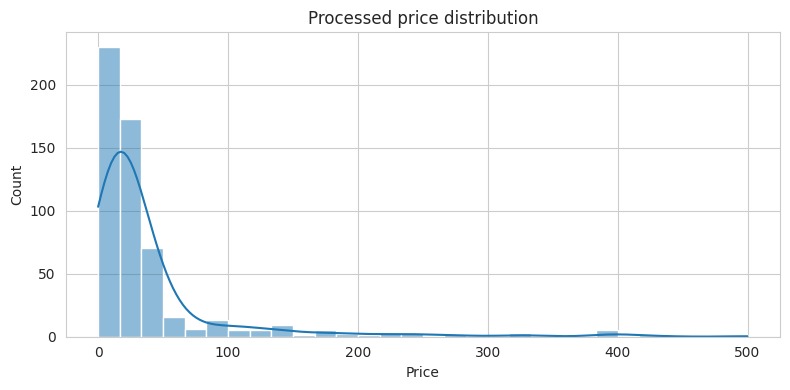


Top categories (processed):


category
uncategorized    240
accessories      123
warranty          52
combos            29
by shape          28
blenders          22
runner rugs       22
supplements       15
containers        14
cheesonings       12
customizer         9
coffee             8
everyday           7
hats               7
outlaws            6
Name: count, dtype: int64


Feature columns available: 50

Feature numeric summary:


,count,mean,std,min,25%,50%,75%,max
price,554.0,39.191354,63.892698,0.00,11.0000,19.990000,35.990000,499.990000
old_price,88.0,21.090227,24.833104,6.49,7.4900,13.980000,21.490000,181.290000
rating,101.0,4.429366,0.666462,1.00,4.2899,4.604651,4.875000,5.000000
review_count,634.0,41.940063,298.225335,0.00,0.0000,0.000000,0.000000,4219.000000
discount_pct,634.0,0.028236,0.089172,0.00,0.0000,0.000000,0.000000,0.750000
popularity_proxy,634.0,0.056611,0.123684,0.00,0.0000,0.000000,0.020027,0.605136


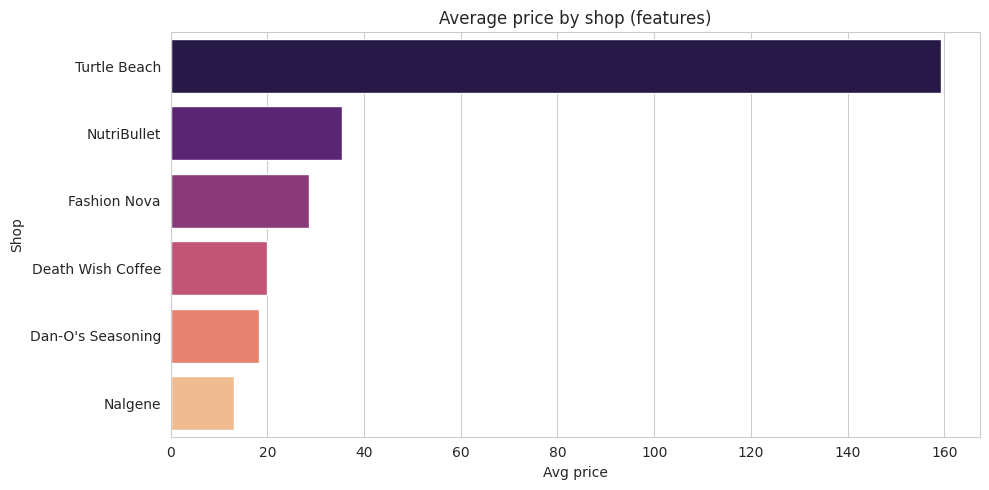


=== ANALYTICS AUDIT ===
Analytics files found: 11


,file,size_kb
0,association_rules.csv,154.41
1,clusters.csv,55.68
2,dbscan_clusters.csv,50.45
3,llm_usage_log.jsonl,12.03
4,mcp_access_log.jsonl,18.71
5,model_metrics.json,2.20
6,model_metrics_xgboost.json,1.42
7,pca_viz.csv,25.62
8,topk_per_category.csv,144.98
9,topk_per_shop.csv,57.07


topk_products.csv: (50, 51)
topk_per_category.csv: (177, 50)
topk_per_shop.csv: (78, 49)
association_rules.csv: (630, 14)
clusters.csv: (634, 6)
dbscan_clusters.csv: (634, 5)
pca_viz.csv: (634, 3)

Model metrics summary:


,model,accuracy,precision,recall,f1,n_samples,n_features
0,RandomForest,1.0,1.0,1.0,1.0,634,13
1,XGBoost,1.0,1.0,1.0,1.0,634,13



Top-K overview:
Rows: 50
Shops: 2
Categories: 7


,title,shop_name,category,score,price,rating,review_count
0,Natalee Biker Shorts Black,Fashion Nova,uncategorized,0.605136,6.00,4.359090,4219
1,Gift Cards,Fashion Nova,uncategorized,0.555846,10.00,4.512296,3375
2,Almost Every Day Leggings Black,Fashion Nova,uncategorized,0.555226,9.00,4.311448,3564
3,On The Go Fleece Pant Set Charcoal,Fashion Nova,uncategorized,0.477225,39.99,4.705628,2079
4,Tall Adriana Flare Pant Black,Fashion Nova,uncategorized,0.440973,12.00,4.672285,1602
5,12oz On-The-Fly Kids Bottle with Graphic,Nalgene,kids water bottles,0.420701,10.99,5.000000,1
6,20oz Multi-Drink Bottle,Nalgene,by shape,0.416782,9.99,5.000000,1
7,Vibe Check Curvy Stretch Skinny Jeans Medium Wash,Fashion Nova,uncategorized,0.414348,15.00,4.289900,1604
8,Are We Clear Sandal Clear,Fashion Nova,uncategorized,0.413209,10.00,4.445296,1435
9,24oz Neoprene Sleeve,Nalgene,accessories,0.408591,5.00,4.000000,1


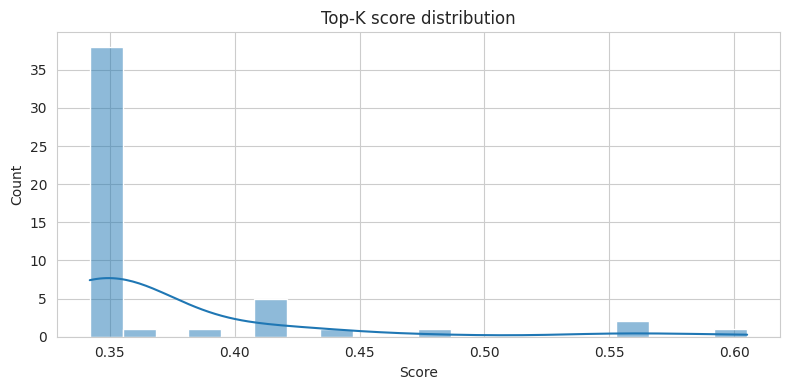


Association rules quality:
Total rules: 630
Avg support: 0.1031
Avg confidence: 0.6937
Avg lift: 2.5431
Strong rules (confidence>=0.6 & lift>=2.0): 204


,antecedents,consequents,support,confidence,lift
600,"platform:shopify, price:low","brand:Ruggable, cat:uncategorized, out_of_stock",0.077287,0.563218,7.287356
604,"brand:Ruggable, cat:uncategorized","out_of_stock, platform:shopify, price:low",0.077287,1.000000,7.287356
593,"brand:Ruggable, cat:uncategorized, out_of_stock","platform:shopify, price:low",0.077287,1.000000,7.287356
467,"out_of_stock, platform:shopify, price:low",brand:Ruggable,0.111987,0.816092,7.287356
475,"brand:Ruggable, out_of_stock","platform:shopify, price:low",0.111987,1.000000,7.287356
472,"platform:shopify, price:low","brand:Ruggable, out_of_stock",0.111987,0.816092,7.287356
479,brand:Ruggable,"out_of_stock, platform:shopify, price:low",0.111987,1.000000,7.287356
589,"out_of_stock, platform:shopify, price:low","brand:Ruggable, cat:uncategorized",0.077287,0.563218,7.287356
463,"platform:shopify, price:low","brand:Ruggable, cat:uncategorized",0.077287,0.563218,7.287356
461,"brand:Ruggable, cat:uncategorized","platform:shopify, price:low",0.077287,1.000000,7.287356



KMeans cluster distribution:


cluster
0    327
1     53
2    209
3     45
Name: count, dtype: int64

DBSCAN outliers: 54


dbscan_cluster
-1     54
 0    127
 1     45
 2     58
 3    312
 4     22
 5     11
 6      5
Name: count, dtype: int64


=== CROSS-LAYER CONSISTENCY ===


,layer,rows
0,raw,634
1,processed_clean,634
2,processed_features,634
3,analytics_topk,50


Retention raw -> cleaned: 100.0%
Retention cleaned -> features: 100.0%

=== PRIORITIZED DATA-QUALITY GAPS ===


,issue,severity_ratio,recommended_action
2,Rating coverage gap,84.1%,Expand rating extraction from JSON-LD/widgets and set source-specific fallbacks
1,Uncategorized share,37.9%,Improve category inference from breadcrumbs/collections/product_type
0,Missing price coverage,12.6%,Add fallback selectors/API enrichment and price normalization guards
3,Core-key duplicate rate,0.0%,Strengthen dedup keys and canonical URL normalization


In [16]:
# =========================================================
# 1) RAW SCRAPE AUDIT
# =========================================================
raw_records = []

for platform, folder in [("shopify", SHOPIFY_DIR), ("woocommerce", WOOCOMMERCE_DIR)]:
    if not folder.exists():
        continue
    for file_path in sorted(folder.glob("*.json")):
        if file_path.name.startswith(".") or file_path.name == "products.json":
            continue
        payload = safe_read_json(file_path)
        rows = normalize_raw_records(payload, file_path.name, platform)
        raw_records.extend(rows)

raw_df = pd.DataFrame(raw_records)
print("=== RAW AUDIT ===")
print("Raw records loaded:", len(raw_df))
print("Raw columns:", list(raw_df.columns))

if raw_df.empty:
    print("No raw records found. Check scraper outputs under data/raw/")
else:
    display(raw_df.head(5))

    # Required-field coverage at raw stage
    required_cols = ["product_id", "title", "product_url", "price", "category", "shop_name"]
    coverage_rows = []
    for c in required_cols:
        if c in raw_df.columns:
            filled = raw_df[c].notna().sum()
            if raw_df[c].dtype == object:
                filled = (raw_df[c].fillna("").astype(str).str.strip() != "").sum()
            coverage_rows.append({
                "field": c,
                "filled": int(filled),
                "total": int(len(raw_df)),
                "coverage": float(filled / len(raw_df)) if len(raw_df) else 0.0,
            })
    raw_coverage = pd.DataFrame(coverage_rows).sort_values("coverage")
    print("\nRaw required-field coverage:")
    display(raw_coverage.style.format({"coverage": "{:.1%}"}))

    # Duplicate diagnostics (same URL or same title+shop)
    dupe_url = raw_df["product_url"].duplicated(keep=False).sum() if "product_url" in raw_df.columns else 0
    if {"title", "shop_name"}.issubset(raw_df.columns):
        dupe_title_shop = raw_df.duplicated(subset=["title", "shop_name"], keep=False).sum()
    else:
        dupe_title_shop = 0
    print(f"Potential duplicates by URL: {dupe_url}")
    print(f"Potential duplicates by (title, shop): {dupe_title_shop}")

    # Platform/shop counts
    if "source_platform" in raw_df.columns:
        print("\nRecords by platform:")
        display(raw_df["source_platform"].value_counts())

    if "shop_name" in raw_df.columns:
        shop_counts = raw_df["shop_name"].fillna("<missing>").value_counts().head(20)
        print("\nTop shops by raw record count:")
        display(shop_counts)

        plt.figure(figsize=(10, 5))
        sns.barplot(x=shop_counts.values, y=shop_counts.index, hue=shop_counts.index, legend=False, palette="viridis")
        plt.title("Raw record volume by shop (top 20)")
        plt.xlabel("Rows")
        plt.ylabel("Shop")
        plt.tight_layout()
        plt.show()

# =========================================================
# 2) PROCESSED LAYER AUDIT
# =========================================================
print("\n=== PROCESSED AUDIT ===")
cleaned_path = PROCESSED_DIR / "cleaned_products.parquet"
features_path = PROCESSED_DIR / "features.parquet"
dq_counters_path = PROCESSED_DIR / "dq_counters.json"

df_clean = pd.read_parquet(cleaned_path) if cleaned_path.exists() else pd.DataFrame()
df_feat = pd.read_parquet(features_path) if features_path.exists() else pd.DataFrame()
dq_counters = safe_read_json(dq_counters_path) if dq_counters_path.exists() else {}

print("cleaned_products shape:", df_clean.shape)
print("features shape:", df_feat.shape)

if dq_counters:
    print("\nDQ counters artifact (dq_counters.json):")
    dq_df = pd.DataFrame([dq_counters]).T.rename(columns={0: "value"})
    display(dq_df)

    dq_plot_keys = [
        "missing_price",
        "missing_category",
        "missing_rating",
        "duplicates_core_key",
        "rows_dropped_required",
        "rows_dropped_dedup",
    ]
    dq_plot = dq_df.loc[dq_df.index.intersection(dq_plot_keys)].copy()
    dq_plot["value"] = pd.to_numeric(dq_plot["value"], errors="coerce")
    dq_plot = dq_plot.dropna().sort_values("value", ascending=False)

    if not dq_plot.empty:
        plt.figure(figsize=(10, 4))
        sns.barplot(x=dq_plot["value"].values, y=dq_plot.index, hue=dq_plot.index, legend=False, palette="crest")
        plt.title("DQ counters snapshot (processed)")
        plt.xlabel("Rows")
        plt.ylabel("Counter")
        plt.tight_layout()
        plt.show()
else:
    print("\nDQ counters artifact not found at:", dq_counters_path)

if not df_clean.empty:
    print("\nCleaned sample:")
    keep = [c for c in ["product_id", "title", "shop_name", "source_platform", "category", "price", "rating", "review_count"] if c in df_clean.columns]
    display(df_clean[keep].head(8))

    # quality checks
    quality = {}
    quality["missing_product_id"] = int(df_clean["product_id"].isna().sum()) if "product_id" in df_clean.columns else None
    quality["missing_title"] = int(df_clean["title"].isna().sum()) if "title" in df_clean.columns else None
    quality["missing_url"] = int(df_clean["product_url"].isna().sum()) if "product_url" in df_clean.columns else None
    quality["missing_price"] = int(df_clean["price"].isna().sum()) if "price" in df_clean.columns else None
    quality["uncategorized"] = int((df_clean.get("category", "").fillna("uncategorized").astype(str).str.lower().isin(["", "none", "uncategorized"])).sum()) if "category" in df_clean.columns else None

    if {"source_platform", "shop_name", "product_id"}.issubset(df_clean.columns):
        quality["duplicate_core_key"] = int(df_clean.duplicated(subset=["source_platform", "shop_name", "product_id"], keep=False).sum())
    else:
        quality["duplicate_core_key"] = None

    print("\nProcessed quality counters:")
    display(pd.DataFrame([quality]).T.rename(columns={0: "count"}))

    if "price" in df_clean.columns and df_clean["price"].notna().any():
        plt.figure(figsize=(8, 4))
        sns.histplot(df_clean["price"].dropna(), bins=30, kde=True)
        plt.title("Processed price distribution")
        plt.xlabel("Price")
        plt.tight_layout()
        plt.show()

    if "category" in df_clean.columns:
        top_cat = df_clean["category"].fillna("<missing>").value_counts().head(15)
        print("\nTop categories (processed):")
        display(top_cat)

if not df_feat.empty:
    print("\nFeature columns available:", len(df_feat.columns))
    numeric_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()
    key_numeric = [c for c in ["price", "old_price", "rating", "review_count", "discount_pct", "popularity_proxy", "score"] if c in numeric_cols]
    if key_numeric:
        print("\nFeature numeric summary:")
        display(df_feat[key_numeric].describe().T)

    if {"shop_name", "price"}.issubset(df_feat.columns):
        avg_price_shop = df_feat.groupby("shop_name")["price"].mean().dropna().sort_values(ascending=False).head(15)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=avg_price_shop.values, y=avg_price_shop.index, hue=avg_price_shop.index, legend=False, palette="magma")
        plt.title("Average price by shop (features)")
        plt.xlabel("Avg price")
        plt.ylabel("Shop")
        plt.tight_layout()
        plt.show()

# =========================================================
# 3) ANALYTICS OUTPUT AUDIT
# =========================================================
print("\n=== ANALYTICS AUDIT ===")
analytics_files = sorted([p for p in ANALYTICS_DIR.glob("*") if p.is_file() and not p.name.startswith(".")])
print("Analytics files found:", len(analytics_files))
display(pd.DataFrame({"file": [p.name for p in analytics_files], "size_kb": [round(p.stat().st_size / 1024, 2) for p in analytics_files]}))

# Load core analytics outputs
core_csvs = [
    "topk_products.csv",
    "topk_per_category.csv",
    "topk_per_shop.csv",
    "association_rules.csv",
    "clusters.csv",
    "dbscan_clusters.csv",
    "pca_viz.csv",
]
analytics = {}
for f in core_csvs:
    path = ANALYTICS_DIR / f
    analytics[f] = pd.read_csv(path) if path.exists() else pd.DataFrame()
    print(f"{f}: {analytics[f].shape}")

# Model metrics JSON
metrics_rf = safe_read_json(ANALYTICS_DIR / "model_metrics.json") or {}
metrics_xgb = safe_read_json(ANALYTICS_DIR / "model_metrics_xgboost.json") or {}

if metrics_rf or metrics_xgb:
    model_rows = []
    for m in [metrics_rf, metrics_xgb]:
        if not m:
            continue
        model_rows.append({
            "model": m.get("model"),
            "accuracy": m.get("accuracy"),
            "precision": m.get("precision"),
            "recall": m.get("recall"),
            "f1": m.get("f1"),
            "n_samples": m.get("n_samples"),
            "n_features": m.get("n_features"),
        })
    print("\nModel metrics summary:")
    display(pd.DataFrame(model_rows))

topk_df = analytics.get("topk_products.csv", pd.DataFrame())
if not topk_df.empty:
    print("\nTop-K overview:")
    print("Rows:", len(topk_df))
    print("Shops:", topk_df["shop_name"].nunique() if "shop_name" in topk_df.columns else "n/a")
    print("Categories:", topk_df["category"].nunique() if "category" in topk_df.columns else "n/a")

    if "score" in topk_df.columns:
        display(topk_df[[c for c in ["title", "shop_name", "category", "score", "price", "rating", "review_count"] if c in topk_df.columns]].head(10))
        plt.figure(figsize=(8, 4))
        sns.histplot(topk_df["score"].dropna(), bins=20, kde=True)
        plt.title("Top-K score distribution")
        plt.xlabel("Score")
        plt.tight_layout()
        plt.show()

rules_df = analytics.get("association_rules.csv", pd.DataFrame())
if not rules_df.empty and {"support", "confidence", "lift"}.issubset(rules_df.columns):
    print("\nAssociation rules quality:")
    print("Total rules:", len(rules_df))
    print("Avg support:", round(rules_df["support"].mean(), 4))
    print("Avg confidence:", round(rules_df["confidence"].mean(), 4))
    print("Avg lift:", round(rules_df["lift"].mean(), 4))

    strong_rules = rules_df[(rules_df["confidence"] >= 0.6) & (rules_df["lift"] >= 2.0)]
    print("Strong rules (confidence>=0.6 & lift>=2.0):", len(strong_rules))
    display(rules_df.sort_values("lift", ascending=False).head(10)[[c for c in ["antecedents", "consequents", "support", "confidence", "lift"] if c in rules_df.columns]])

clusters_df = analytics.get("clusters.csv", pd.DataFrame())
dbscan_df = analytics.get("dbscan_clusters.csv", pd.DataFrame())
if not clusters_df.empty and "cluster" in clusters_df.columns:
    print("\nKMeans cluster distribution:")
    display(clusters_df["cluster"].value_counts().sort_index())

if not dbscan_df.empty and "dbscan_cluster" in dbscan_df.columns:
    outliers = int((dbscan_df["dbscan_cluster"] == -1).sum())
    print("DBSCAN outliers:", outliers)
    display(dbscan_df["dbscan_cluster"].value_counts().sort_index())

# =========================================================
# 4) CROSS-LAYER CONSISTENCY CHECKS
# =========================================================
print("\n=== CROSS-LAYER CONSISTENCY ===")

raw_count = len(raw_df) if not raw_df.empty else 0
clean_count = len(df_clean) if not df_clean.empty else 0
feat_count = len(df_feat) if not df_feat.empty else 0
topk_count = len(topk_df) if not topk_df.empty else 0

consistency = pd.DataFrame(
    [
        {"layer": "raw", "rows": raw_count},
        {"layer": "processed_clean", "rows": clean_count},
        {"layer": "processed_features", "rows": feat_count},
        {"layer": "analytics_topk", "rows": topk_count},
    ]
)
display(consistency)

if clean_count and raw_count:
    print("Retention raw -> cleaned:", pct(clean_count / raw_count))
if feat_count and clean_count:
    print("Retention cleaned -> features:", pct(feat_count / clean_count))

# =========================================================
# 5) PRIORITIZED DATA-QUALITY GAPS (AUTO-SUMMARY)
# =========================================================
print("\n=== PRIORITIZED DATA-QUALITY GAPS ===")
issues = []

if not df_clean.empty:
    if "price" in df_clean.columns:
        miss_price = float(df_clean["price"].isna().mean())
        issues.append(("Missing price coverage", miss_price, "Add fallback selectors/API enrichment and price normalization guards"))

    if "category" in df_clean.columns:
        unc = df_clean["category"].fillna("uncategorized").astype(str).str.lower().isin(["", "none", "uncategorized"]).mean()
        issues.append(("Uncategorized share", float(unc), "Improve category inference from breadcrumbs/collections/product_type"))

    if "rating" in df_clean.columns:
        rated = (df_clean["rating"].fillna(0) > 0).mean()
        issues.append(("Rating coverage gap", float(1 - rated), "Expand rating extraction from JSON-LD/widgets and set source-specific fallbacks"))

    if {"source_platform", "shop_name", "product_id"}.issubset(df_clean.columns):
        dup = df_clean.duplicated(subset=["source_platform", "shop_name", "product_id"], keep=False).mean()
        issues.append(("Core-key duplicate rate", float(dup), "Strengthen dedup keys and canonical URL normalization"))

if issues:
    gap_df = pd.DataFrame(issues, columns=["issue", "severity_ratio", "recommended_action"]).sort_values("severity_ratio", ascending=False)
    display(gap_df.style.format({"severity_ratio": "{:.1%}"}))
else:
    print("No processed-layer issues computed (missing processed data).")


=== EXTRACTION STATUS & RECORD DQ ===

price_status breakdown:


price_status
found                554
extraction_failed     80
Name: count, dtype: int64


category_status breakdown:


category_status
found                394
missing              123
extraction_failed    117
Name: count, dtype: int64


rating_status breakdown:


...

taxonomy_evidence_strength,high,low,medium,none
source_platform,,,,
shopify,166,0,0,67
woocommerce,342,2,1,56



DQ score summary:


count    634.000000
mean      83.459779
std       11.223932
min       49.500000
25%       79.000000
50%       89.500000
75%       89.500000
max      100.000000
Name: dq_score, dtype: float64


DQ score by platform:


,count,mean,25%,50%,75%,max
source_platform,,,,,,
shopify,233.0,74.281116,69.5,79.0,85.0,89.5
woocommerce,401.0,88.793017,89.5,89.5,89.5,100.0


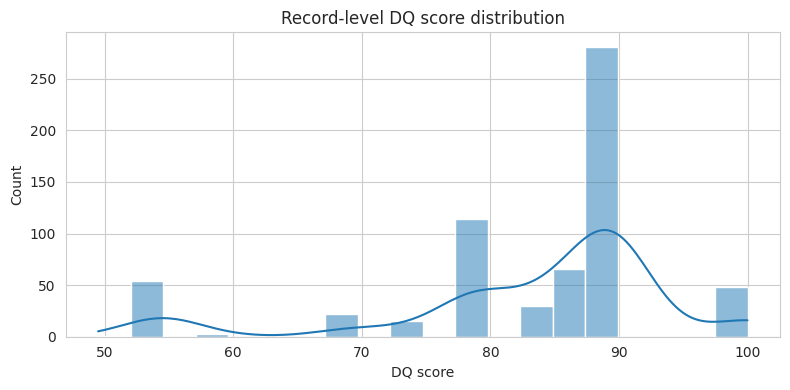

In [17]:
# =========================================================
# 6) EXTRACTION STATUS & RECORD-LEVEL DQ QUALITY
# =========================================================
print("\n=== EXTRACTION STATUS & RECORD DQ ===")

if df_clean.empty:
    print("No cleaned data to summarize.")
else:
    status_cols = [c for c in ["price_status", "category_status", "rating_status"] if c in df_clean.columns]
    source_cols = [c for c in ["price_source", "category_source", "rating_source"] if c in df_clean.columns]
    evidence_cols = [
        c
        for c in [
            "taxonomy_evidence_strength",
            "taxonomy_sources_detected",
            "taxonomy_breadcrumb_present",
            "taxonomy_jsonld_category_present",
            "taxonomy_jsonld_breadcrumb_present",
            "taxonomy_product_type_present",
            "taxonomy_tags_present",
            "taxonomy_url_hint_present",
        ]
        if c in df_clean.columns
    ]

    for col in status_cols:
        print(f"\n{col} breakdown:")
        display(df_clean[col].value_counts(dropna=False))

    for col in source_cols:
        print(f"\n{col} breakdown:")
        display(df_clean[col].value_counts(dropna=False).head(10))

    for col in evidence_cols:
        print(f"\n{col} breakdown:")
        display(df_clean[col].value_counts(dropna=False).head(20))

    if "source_platform" in df_clean.columns:
        for col in status_cols:
            print(f"\n{col} by platform:")
            status_platform = (
                df_clean.groupby("source_platform")[col]
                .value_counts(dropna=False)
                .unstack(fill_value=0)
            )
            display(status_platform)

        if "taxonomy_evidence_strength" in df_clean.columns:
            print("\ncategory taxonomy_evidence_strength by platform:")
            strength_platform = (
                df_clean.groupby("source_platform")["taxonomy_evidence_strength"]
                .value_counts(dropna=False)
                .unstack(fill_value=0)
            )
            display(strength_platform)

    if "dq_score" in df_clean.columns:
        print("\nDQ score summary:")
        display(df_clean["dq_score"].describe())

        if "source_platform" in df_clean.columns:
            print("\nDQ score by platform:")
            display(df_clean.groupby("source_platform")["dq_score"].describe()[["count", "mean", "25%", "50%", "75%", "max"]])

        plt.figure(figsize=(8, 4))
        sns.histplot(df_clean["dq_score"].dropna(), bins=20, kde=True)
        plt.title("Record-level DQ score distribution")
        plt.xlabel("DQ score")
        plt.tight_layout()
        plt.show()
    else:
        print("dq_score column not present. Re-run preprocessing to generate it.")

In [18]:
# =========================================================
# 7) MANUAL CATEGORY STATUS AUDIT (20-ROW STRATIFIED SAMPLE)
# =========================================================
print("\n=== MANUAL CATEGORY STATUS AUDIT (20 ROWS) ===")

audit_path = ANALYTICS_DIR / "category_audit_labeled_20.csv"
if not audit_path.exists():
    print(f"Audit file not found: {audit_path}")
    print("Generate it from the latest sample before running this section.")
else:
    audit_df = pd.read_csv(audit_path)
    print("Audit rows:", len(audit_df))
    display(audit_df[[
        c
        for c in [
            "audit_id",
            "source_platform",
            "shop_name",
            "product_url",
            "category_status",
            "category_source",
            "taxonomy_evidence_strength",
            "taxonomy_sources_detected",
            "live_taxonomy_evidence_strength",
            "live_taxonomy_sources_detected",
            "root_cause_tag",
            "audit_bucket",
            "label_is_correct",
        ]
        if c in audit_df.columns
    ]])

    if {"category_status", "label_is_correct"}.issubset(audit_df.columns):
        precision_df = (
            audit_df.groupby("category_status", dropna=False)["label_is_correct"]
            .mean()
            .mul(100)
            .round(1)
            .rename("precision_percent")
            .reset_index()
        )
        print("\nPrecision by category_status (sample):")
        display(precision_df)

    if "audit_bucket" in audit_df.columns:
        print("\nFailure taxonomy (sample counts):")
        display(audit_df["audit_bucket"].value_counts(dropna=False))

    if "root_cause_tag" in audit_df.columns:
        print("\nRoot-cause tags (sample counts):")
        root_counts = audit_df["root_cause_tag"].value_counts(dropna=False)
        display(root_counts)

    print("\nPrioritized heuristic fixes (impact-ranked):")
    fixes = [
        "1) Shopify: parse BreadcrumbList leaf category from JSON-LD itemListElement and map to canonical category.",
        "2) WooCommerce: add HTML fallback taxonomy evidence pass when Store API categories/tags are empty.",
        "3) Validation: if live-equivalent high evidence markers are present, forbid category_status='missing' (route to extraction_failed).",
        "4) Keep tags as weak evidence only; never upgrade to direct category without breadcrumb/category field confirmation.",
        "5) Preserve full breadcrumb path before normalization for later alias mapping.",
    ]
    for line in fixes:
        print(" -", line)

    if "taxonomy_evidence_strength" in audit_df.columns and "label_is_correct" in audit_df.columns:
        print("\nThreshold recommendation:")
        print(
            "Keep current evidence-strength thresholds for now; issue is translation/capture, not thresholding. "
            "Re-evaluate thresholds after Shopify breadcrumb extraction patch lands."
        )


=== MANUAL CATEGORY STATUS AUDIT (20 ROWS) ===
Audit rows: 20


,audit_id,source_platform,shop_name,product_url,category_status,category_source,taxonomy_evidence_strength,taxonomy_sources_detected,live_taxonomy_evidence_strength,live_taxonomy_sources_detected,root_cause_tag,audit_bucket,label_is_correct
0,A01,shopify,Turtle Beach,https://www.turtlebeach.com/products/victrix-t...,missing,none,none,NaN,none,NaN,true_no_taxonomy,page truly has no usable category,True
1,A02,shopify,Turtle Beach,https://www.turtlebeach.com/products/kone-ii-m...,missing,none,none,NaN,none,NaN,true_no_taxonomy,page truly has no usable category,True
2,A03,shopify,Turtle Beach,https://www.turtlebeach.com/products/atlas-200...,missing,none,none,NaN,none,NaN,true_no_taxonomy,page truly has no usable category,True
3,A04,shopify,Turtle Beach,https://www.turtlebeach.com/products/pdp-after...,missing,none,none,NaN,none,NaN,true_no_taxonomy,page truly has no usable category,True
4,A05,shopify,Turtle Beach,https://www.turtlebeach.com/products/pdp-airli...,missing,none,none,NaN,none,NaN,true_no_taxonomy,page truly has no usable category,True
5,A06,woocommerce,Dan-O's Seasoning,https://danosseasoning.com/product/cajun-seaso...,missing,none,none,NaN,high,jsonld_breadcrumb,source_specific_capture_gap_woocommerce,category clearly present and parser missed it,False
6,A07,woocommerce,Dan-O's Seasoning,https://danosseasoning.com/product/red-pepper-...,missing,none,none,NaN,high,jsonld_breadcrumb,source_specific_capture_gap_woocommerce,category clearly present and parser missed it,False
7,A08,woocommerce,Dan-O's Seasoning,https://danosseasoning.com/product/preem-o-sea...,missing,none,none,NaN,high,jsonld_breadcrumb,source_specific_capture_gap_woocommerce,category clearly present and parser missed it,False
8,A09,woocommerce,Dan-O's Seasoning,https://danosseasoning.com/product/chili-lime-...,missing,none,none,NaN,high,jsonld_breadcrumb,source_specific_capture_gap_woocommerce,category clearly present and parser missed it,False
9,A10,woocommerce,Dan-O's Seasoning,https://danosseasoning.com/product/spicy-seaso...,missing,none,none,NaN,high,jsonld_breadcrumb,source_specific_capture_gap_woocommerce,category clearly present and parser missed it,False



Precision by category_status (sample):


,category_status,precision_percent
0,extraction_failed,100.0
1,missing,50.0



Failure taxonomy (sample counts):


audit_bucket
category clearly present and parser missed it    15
page truly has no usable category                 5
Name: count, dtype: int64


Root-cause tags (sample counts):


root_cause_tag
jsonld_breadcrumb_translation_gap_shopify        9
true_no_taxonomy                                 5
source_specific_capture_gap_woocommerce          5
jsonld_breadcrumb_translation_gap_woocommerce    1
Name: count, dtype: int64


Prioritized heuristic fixes (impact-ranked):
 - 1) Shopify: parse BreadcrumbList leaf category from JSON-LD itemListElement and map to canonical category.
 - 2) WooCommerce: add HTML fallback taxonomy evidence pass when Store API categories/tags are empty.
 - 3) Validation: if live-equivalent high evidence markers are present, forbid category_status='missing' (route to extraction_failed).
 - 4) Keep tags as weak evidence only; never upgrade to direct category without breadcrumb/category field confirmation.
 - 5) Preserve full breadcrumb path before normalization for later alias mapping.

Threshold recommendation:
Keep current evidence-strength thresholds for now; issue is translation/capture, not thresholding. Re-evaluate thresholds after Shopify breadcrumb extraction patch lands.


## Next Actions for Data-Quality Hardening

Use outputs from the final **PRIORITIZED DATA-QUALITY GAPS** table to drive Sprint item B in this order:

1. **Required fields validator**: enforce `product_id`, `title`, `product_url`, `shop_name`, `source_platform` at scrape time.
2. **Normalization pass**: canonicalize URL, title spacing/case, category aliases, and price unit handling.
3. **Dedup hardening**: apply deterministic dedup key + tie-break policy for competing rows.
4. **Extractor resilience**: add fallback selectors (JSON-LD, alternate DOM paths, API fallback) for each fragile source.
5. **Structured DQ logging**: emit per-shop DQ counters (`missing_price`, `missing_category`, `missing_rating`, `duplicates_dropped`).
6. **Fixture-based tests**: lock in edge-case HTML/API payload samples for sources with layout drift history.

Re-run this notebook after each scraper change to measure quality deltas objectively.